In [ ]:
!pip install -q fastapi uvicorn python-multipart supabase supervision transformers rfdetr scipy python-dotenv rich qrcode[pil] gdown

# Download and install the Cloudflare Tunnel daemon for Linux
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64


In [ ]:
pip install gdown

In [ ]:
import gdown
import os
import shutil

folder_url = 'https://drive.google.com/drive/folders/1QyZTsoNF8Ii2p6Lw_XcfoSUeIzItXxJ3'
print("📂 Downloading Project Files from Google Drive...")
gdown.download_folder(folder_url, quiet=True, use_cookies=False)

# 3. Move files from the downloaded folder to the main directory
# gdown usually creates a folder named after the drive folder or 'Untitled folder'
downloaded_folders = [d for d in os.listdir('.') if os.path.isdir(d) and d not in ['.config', 'sample_data']]
if downloaded_folders:
    source_folder = downloaded_folders[0]
    for filename in os.listdir(source_folder):
        shutil.move(os.path.join(source_folder, filename), os.path.join('.', filename))
    print(f"✅ Successfully moved files from {source_folder} to root.")


# 5. Verify files exist
print("\n📝 Current Files in Runtime:")
!ls -lh

📂 Downloading Project Files from Google Drive...
✅ Successfully moved files from Road Eye to root.

📝 Current Files in Runtime:
total 421M
-rw-r--r-- 1 root root 383M Mar 17 13:22  checkpoint_best_ema.pth
-rwxr-xr-x 1 root root  38M Mar  9 14:17  cloudflared-linux-amd64
-rw-r--r-- 1 root root 1.5K Mar 17 13:18  feature_extractor.py
drwxr-xr-x 2 root root 4.0K Mar 17 13:25 'Road Eye'
drwxr-xr-x 1 root root 4.0K Jan 16 14:24  sample_data


In [ ]:
%%writefile server.py
import os
import cv2
import socket
import base64
import numpy as np
import torch
import math
import time
from datetime import datetime
from PIL import Image
from dotenv import load_dotenv

import uvicorn
from fastapi import FastAPI, HTTPException, BackgroundTasks, Request
from pydantic import BaseModel
from supabase import create_client, Client
from scipy.spatial.distance import cosine

# --- BEAUTIFUL TERMINAL IMPORTS ---
from rich.console import Console
from rich.panel import Panel
from rich.text import Text
from rich.table import Table
from rich.theme import Theme

# Setup custom theme
custom_theme = Theme({
    "info": "cyan",
    "warning": "yellow",
    "error": "bold red",
    "success": "bold green",
    "user": "bold magenta"
})
console = Console(theme=custom_theme)

# =====================================================================
# --- SYSTEM TRACKERS ---
# =====================================================================
active_users = {} # Track last activity of users {email: timestamp}

def log_event(user_email, status, message, color="white"):
    """Custom formatter for beautiful logs"""
    timestamp = datetime.now().strftime("%H:%M:%S")
    user_tag = Text(f"[{user_email}]", style="user")
    time_tag = Text(f"({timestamp}) ", style="dim")

    if status == "DETECTION":
        content = Text.assemble(time_tag, user_tag, (f" 🚨 {message}", "bold red"))
    elif status == "CLEAR":
        content = Text.assemble(time_tag, user_tag, (f" ✅ {message}", "success"))
    elif status == "CONN":
        content = Text.assemble(time_tag, user_tag, (f" 📡 {message}", "info"))
    else:
        content = Text.assemble(time_tag, user_tag, f" {message}")

    console.print(content)

# =====================================================================
# --- THE ROBUST FIX: DYNAMIC SHAPE INTERPOLATOR & SECURITY BYPASS ---
# =====================================================================

original_load = torch.load
def safe_load(*args, **kwargs):
    kwargs['weights_only'] = False
    return original_load(*args, **kwargs)
torch.load = safe_load

original_load_state_dict = torch.nn.Module.load_state_dict

def dynamic_resize_load_state_dict(self, state_dict, strict=True, assign=False):
    my_state = self.state_dict()
    for k, v in list(state_dict.items()):
        if k in my_state:
            target_shape = my_state[k].shape
            if v.shape != target_shape:
                if 'position_embeddings' in k and len(v.shape) == 3 and len(target_shape) == 3:
                    cls_tok = v[:, 0:1, :]
                    pos_tok = v[:, 1:, :]
                    num_patches_old = pos_tok.shape[1]
                    num_patches_new = target_shape[1] - 1
                    grid_old = int(math.sqrt(num_patches_old))
                    grid_new = int(math.sqrt(num_patches_new))
                    if grid_old * grid_old == num_patches_old and grid_new * grid_new == num_patches_new:
                        pos_tok_2d = pos_tok.reshape(1, grid_old, grid_old, -1).permute(0, 3, 1, 2)
                        new_pos_tok_2d = torch.nn.functional.interpolate(pos_tok_2d.float(), size=(grid_new, grid_new), mode='bicubic', align_corners=False)
                        new_pos_tok = new_pos_tok_2d.permute(0, 2, 3, 1).reshape(1, num_patches_new, -1)
                        state_dict[k] = torch.cat((cls_tok, new_pos_tok.to(v.dtype)), dim=1)
                        continue
                if len(v.shape) == 4 and len(target_shape) == 4:
                    if v.shape[:2] == target_shape[:2]:
                        new_v = torch.nn.functional.interpolate(v.float(), size=target_shape[2:], mode='bicubic', align_corners=False)
                        state_dict[k] = new_v.to(v.dtype)
                        continue
                del state_dict[k]
    return original_load_state_dict(self, state_dict, strict=False, assign=assign)

torch.nn.Module.load_state_dict = dynamic_resize_load_state_dict

# =====================================================================

import supervision as sv
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
from rfdetr import RFDETRLarge
from feature_extractor import FeatureExtractor

# --- CONFIGURATION ---
load_dotenv()
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_SECRET_KEY = os.getenv("SUPABASE_SERVICE_ROLE_KEY")
CHECKPOINT_PATH = "/content/checkpoint_best_ema.pth"
CONF_THRESHOLD = 0.4
IMG_SIZE = 640
PORT = 5000

SPATIAL_RADIUS_METERS = 8
VISUAL_SIMILARITY_THRESHOLD = 0.85
HEADING_TOLERANCE_DEGREES = 45

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

app = FastAPI()
supabase: Client = create_client(SUPABASE_URL, SUPABASE_SECRET_KEY)

# --- LOAD MODELS ---
console.print(Panel.fit("🚀 [bold white]ROAD SENSE PRO[/bold white]\n[dim]Initializing Artificial Intelligence System...[/dim]", border_style="cyan"))

with console.status("[bold green]Loading Segformer & RF-DETR Models...") as status:
    processor = SegformerImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-cityscapes-512-1024")
    seg_model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b0-finetuned-cityscapes-512-1024").to(DEVICE)
    seg_model.eval()

    det_model = RFDETRLarge(num_classes=1, pretrain_weights=CHECKPOINT_PATH, resolution=IMG_SIZE)
    det_model.optimize_for_inference()
    resnet_extractor = FeatureExtractor()

console.print("[success]✅ System online and running on[/success] [bold yellow]" + str(DEVICE).upper() + "[/bold yellow]\n")

# --- DATA MODEL ---
class DetectionRequest(BaseModel):
    image: str
    gps: dict
    instance_ip: str
    roughness: float
    user_id: str
    user_email: str
    debug_mode: bool = False

# --- AI HELPERS ---
def get_road_mask(image: Image.Image):
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = seg_model(**inputs)
    logits = torch.nn.functional.interpolate(outputs.logits, size=image.size[::-1], mode="bilinear", align_corners=False)
    mask = logits.argmax(dim=1).squeeze().cpu().numpy()
    road_mask = (mask == 0).astype(np.uint8)
    return cv2.dilate(road_mask, np.ones((15, 15), np.uint8), iterations=1)

def filter_detections_by_road(detections, road_mask, threshold=0.4):
    if len(detections) == 0: return detections
    keep =[]
    for box in detections.xyxy:
        x1, y1, x2, y2 = map(int, box)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(road_mask.shape[1], x2), min(road_mask.shape[0], y2)
        box_area = (x2 - x1) * (y2 - y1)
        if box_area == 0:
            keep.append(False); continue
        box_mask = road_mask[y1:y2, x1:x2]
        road_ratio = np.sum(box_mask) / box_area
        keep.append(road_ratio >= threshold)
    return detections[np.array(keep)]

# --- API ENDPOINT ---
@app.post("/detect")
async def process_request(data: DetectionRequest, background_tasks: BackgroundTasks):
    global active_users
    now = time.time()

    # Check for NEW connection
    if data.user_email not in active_users:
        log_event(data.user_email, "CONN", "User connected to Patrol Node", "info")
    active_users[data.user_email] = now

    try:
        telemetry = {"latitude": data.gps['lat'], "longitude": data.gps['lon'], "roughness": data.roughness, "session_id": data.instance_ip, "user_id": data.user_id, "user_email": data.user_email}
        background_tasks.add_task(supabase.table("road_logs").insert(telemetry).execute)

        img_bytes = base64.b64decode(data.image)
        cv_img = cv2.imdecode(np.frombuffer(img_bytes, np.uint8), cv2.IMREAD_COLOR)
        if cv_img is None: return {"status": "error", "msg": "Invalid Image"}

        pil_image = Image.fromarray(cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB))
        image_area = cv_img.shape[0] * cv_img.shape[1]
        road_mask = get_road_mask(pil_image)

        pil_inf = pil_image.resize((IMG_SIZE, IMG_SIZE))
        raw_detections = det_model.predict(pil_inf, threshold=CONF_THRESHOLD)

        if len(raw_detections) > 0:
            scale_x, scale_y = cv_img.shape[1]/IMG_SIZE, cv_img.shape[0]/IMG_SIZE
            raw_detections.xyxy[:,[0, 2]] *= scale_x
            raw_detections.xyxy[:, [1, 3]] *= scale_y

        hits = filter_detections_by_road(raw_detections, road_mask, threshold=0.3)

        scene = cv_img.copy()

        if data.debug_mode or len(hits) > 0:
            rm_color = np.zeros_like(cv_img)
            rm_color[road_mask == 1] = [0, 255, 0]
            scene = cv2.addWeighted(scene, 1.0, rm_color, 0.15, 0)

        if len(hits) == 0:
            log_event(data.user_email, "CLEAR", f"Patrolling at {data.gps['lat']:.4f}, {data.gps['lon']:.4f} (Road Clear)")
            resp = {"status": "clear"}
            if data.debug_mode:
                _, b = cv2.imencode('.jpg', scene,[int(cv2.IMWRITE_JPEG_QUALITY), 60])
                resp["debug_image"] = base64.b64encode(b.tobytes()).decode('utf-8')
            return resp

        # --- POTHOLE DETECTED ---
        new_dets =[]
        max_severity = "Minor"
        for box, conf in zip(hits.xyxy, hits.confidence):
            x1, y1, x2, y2 = map(int, box)
            x1, y1, x2, y2 = max(0, x1), max(0, y1), min(cv_img.shape[1], x2), min(cv_img.shape[0], y2)
            crop = cv_img[y1:y2, x1:x2]
            if crop.size == 0: continue
            gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
            edges = cv2.Canny(gray, 50, 150)
            score = (0.6 * ((x2-x1)*(y2-y1)/image_area)) + (0.4 * (np.sum(edges>0)/edges.size))
            if score < 0.3: lab, col = "Minor", (0, 255, 0)
            elif score < 0.6: lab, col = "Moderate", (0, 255, 255); max_severity = "Moderate"
            else: lab, col = "Severe", (0, 0, 255); max_severity = "Severe"

            overlay = scene.copy()
            cv2.rectangle(overlay, (x1, y1), (x2, y2), col, -1)
            scene = cv2.addWeighted(overlay, 0.35, scene, 0.65, 0)
            scene[y1:y2, x1:x2][edges > 0] =[255, 255, 255]
            cv2.rectangle(scene, (x1, y1-25), (x2, y1), col, -1)
            cv2.putText(scene, f"{lab} ({conf:.2f})", (x1+5, y1-7), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)
            new_dets.append({"severity": lab, "embedding": resnet_extractor.get_embedding(crop)})

        log_event(data.user_email, "DETECTION", f"FOUND {len(new_dets)} POTHOLE(S)! Max Severity: {max_severity.upper()}")

        _, b = cv2.imencode('.jpg', scene,[int(cv2.IMWRITE_JPEG_QUALITY), 75])
        file_bytes = b.tobytes()
        fname = f"ph_{datetime.now().strftime('%Y%m%d_%H%M%S_%f')}.jpg"
        supabase.storage.from_("pothole-images").upload(fname, file_bytes, {"content-type": "image/jpeg"})
        url = supabase.storage.from_("pothole-images").get_public_url(fname)

        lat, lon, head = data.gps['lat'], data.gps['lon'], data.gps.get('heading', 0.0)
        candidates = supabase.rpc("find_candidates", {"search_lat": lat, "search_lon": lon, "radius_m": SPATIAL_RADIUS_METERS}).execute().data

        for det in new_dets:
            match_id = None
            if candidates:
                for cand in candidates:
                    a_diff = abs(cand['heading'] - head)
                    if a_diff > 180: a_diff = 360 - a_diff
                    if a_diff > HEADING_TOLERANCE_DEGREES: continue
                    sim = 1 - cosine(det["embedding"], np.array(eval(cand['embedding'])))
                    if sim > VISUAL_SIMILARITY_THRESHOLD: match_id = cand['id']; break

            if match_id:
                supabase.table("detections").update({"report_count": cand['report_count'] + 1, "last_seen": datetime.now().isoformat(), "image_url": url}).eq("id", match_id).execute()
            else:
                supabase.table("detections").insert({"latitude": lat, "longitude": lon, "heading": head, "image_url": url, "severity": det["severity"], "user_id": data.user_id, "user_email": data.user_email, "embedding": str(det["embedding"]), "report_count": 1, "last_seen": datetime.now().isoformat()}).execute()

        resp = {"status": "detected", "url": url}
        if data.debug_mode: resp["debug_image"] = base64.b64encode(file_bytes).decode('utf-8')
        return resp

    except Exception as e:
        console.print(f"[error]❌ FATAL ERROR:[/error] {e}")
        raise HTTPException(status_code=500, detail=str(e))

if __name__ == "__main__":
    uvicorn.run(app, host="0.0.0.0", port=PORT, log_level="error") # Shhh uvicorn logs, we have our own!

Overwriting server.py



✅ TUNNEL LIVE!
👉 URL: https://fred-propose-implied-showers.trycloudflare.com

📸 SCAN THIS QR CODE ON YOUR PHONE TO COPY THE URL:


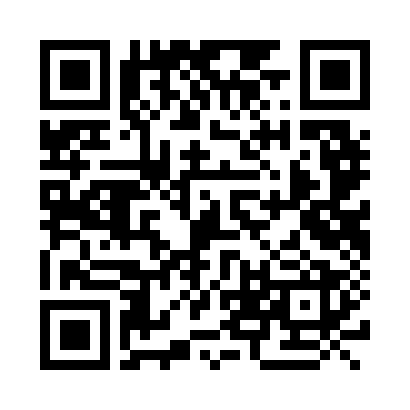


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
🚀 STARTING AI SERVER LOGS BELOW...
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

2026-03-17 13:12:53.731935: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773753173.768209   17521 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773753173.779117   17521 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773753173.827516   17521 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773753173.827567   17521 computation_placer.cc:177] computation placer already registered.

In [ ]:
import subprocess
import time
import os
import re
import qrcode
from IPython.display import display, clear_output
from google.colab import userdata

# 1. Reset old processes
!pkill cloudflared

# 2. Extract secrets (Safe handling)
try:
    with open(".env", "w") as f:
        f.write(f"SUPABASE_URL={userdata.get('SUPABASE_URL')}\n")
        f.write(f"SUPABASE_SERVICE_ROLE_KEY={userdata.get('SUPABASE_SERVICE_ROLE_KEY')}\n")
except: pass

# 3. Start Cloudflare Tunnel
print("🌐 Starting Cloudflare Tunnel (Generating QR Code)...")
tunnel_process = subprocess.Popen(
    ['./cloudflared-linux-amd64', 'tunnel', '--url', 'http://127.0.0.1:5000'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1
)

cf_url = None
start_time = time.time()

# 4. Search for the unique URL
while time.time() - start_time < 30:
    line = tunnel_process.stdout.readline()
    match = re.search(r"https://[a-zA-Z0-9-]+\.trycloudflare\.com", line)
    if match and "api.trycloudflare.com" not in match.group(0):
        cf_url = match.group(0)
        break

if cf_url:
    # --- BEAUTIFUL QR CODE DISPLAY ---
    clear_output() # Clean the "Starting..." text

    print("\n" + "="*60)
    print(f"✅ TUNNEL LIVE!")
    print(f"👉 URL: {cf_url}")
    print("="*60)
    print("\n📸 SCAN THIS QR CODE ON YOUR PHONE TO COPY THE URL:")

    # Generate QR Code
    qr = qrcode.QRCode(version=1, box_size=10, border=4)
    qr.add_data(cf_url)
    qr.make(fit=True)
    img = qr.make_image(fill_color="black", back_color="white")

    # Display it in Colab
    display(img)

    print("\n" + "!" * 60)
    print("🚀 STARTING AI SERVER LOGS BELOW...")
    print("!" * 60 + "\n")

    # 5. Start the Server
    # We use !python to keep the process in the foreground so you see your beautiful Rich logs
    !python server.py
else:
    print("❌ Failed to start tunnel within 30 seconds.")